# Домашнее задание #4: БУСТ 4 ДОМАШКИ

# ***ВНИМАНИЕ! EDA и ответы на вопросы смотреть в другом ноутбуке. здесь только улучшение***

### использованный датасет - цены на бу тойоты короллы
https://www.kaggle.com/datasets/vishakhdapat/price-of-used-toyota-corolla-cars

In [1690]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.datasets import make_blobs, make_classification, make_moons
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge, Lasso
from scipy.spatial.distance import cosine
import pandas as pd
import time

pd.set_option('display.max_columns', None)
sns.set_style('darkgrid')


In [1691]:
df = pd.read_csv("ToyotaCorolla.csv")



In [1692]:

print("Статистики для Price:")
print(f"Среднее: {df['Price'].mean():.2f}")
print(f"Медиана: {df['Price'].median():.2f}")
print(f"Дисперсия: {df['Price'].var():.2f}")
print(f"Асимметрия: {(df['Price']).skew():.2f}")
print(f"Эксцесс: {(df['Price']).kurtosis():.2f}")

Статистики для Price:
Среднее: 10730.82
Медиана: 9900.00
Дисперсия: 13154872.10
Асимметрия: 1.70
Эксцесс: 3.74


# АССИМЕТРИЯ ЦЕНЫ -> НИЖЕ БЕРЕТСЯ ЛОГАРИФМ

# ОБРАБОТКА ВЫБРОСОВ(смотреть объяснение в прошлом коммите)

In [1693]:
df = df[df['CC'] <= 3000]


In [1694]:
df = df[df['Weight'] <= 1600]

In [1695]:
df = df[df['Gears'] > 4]

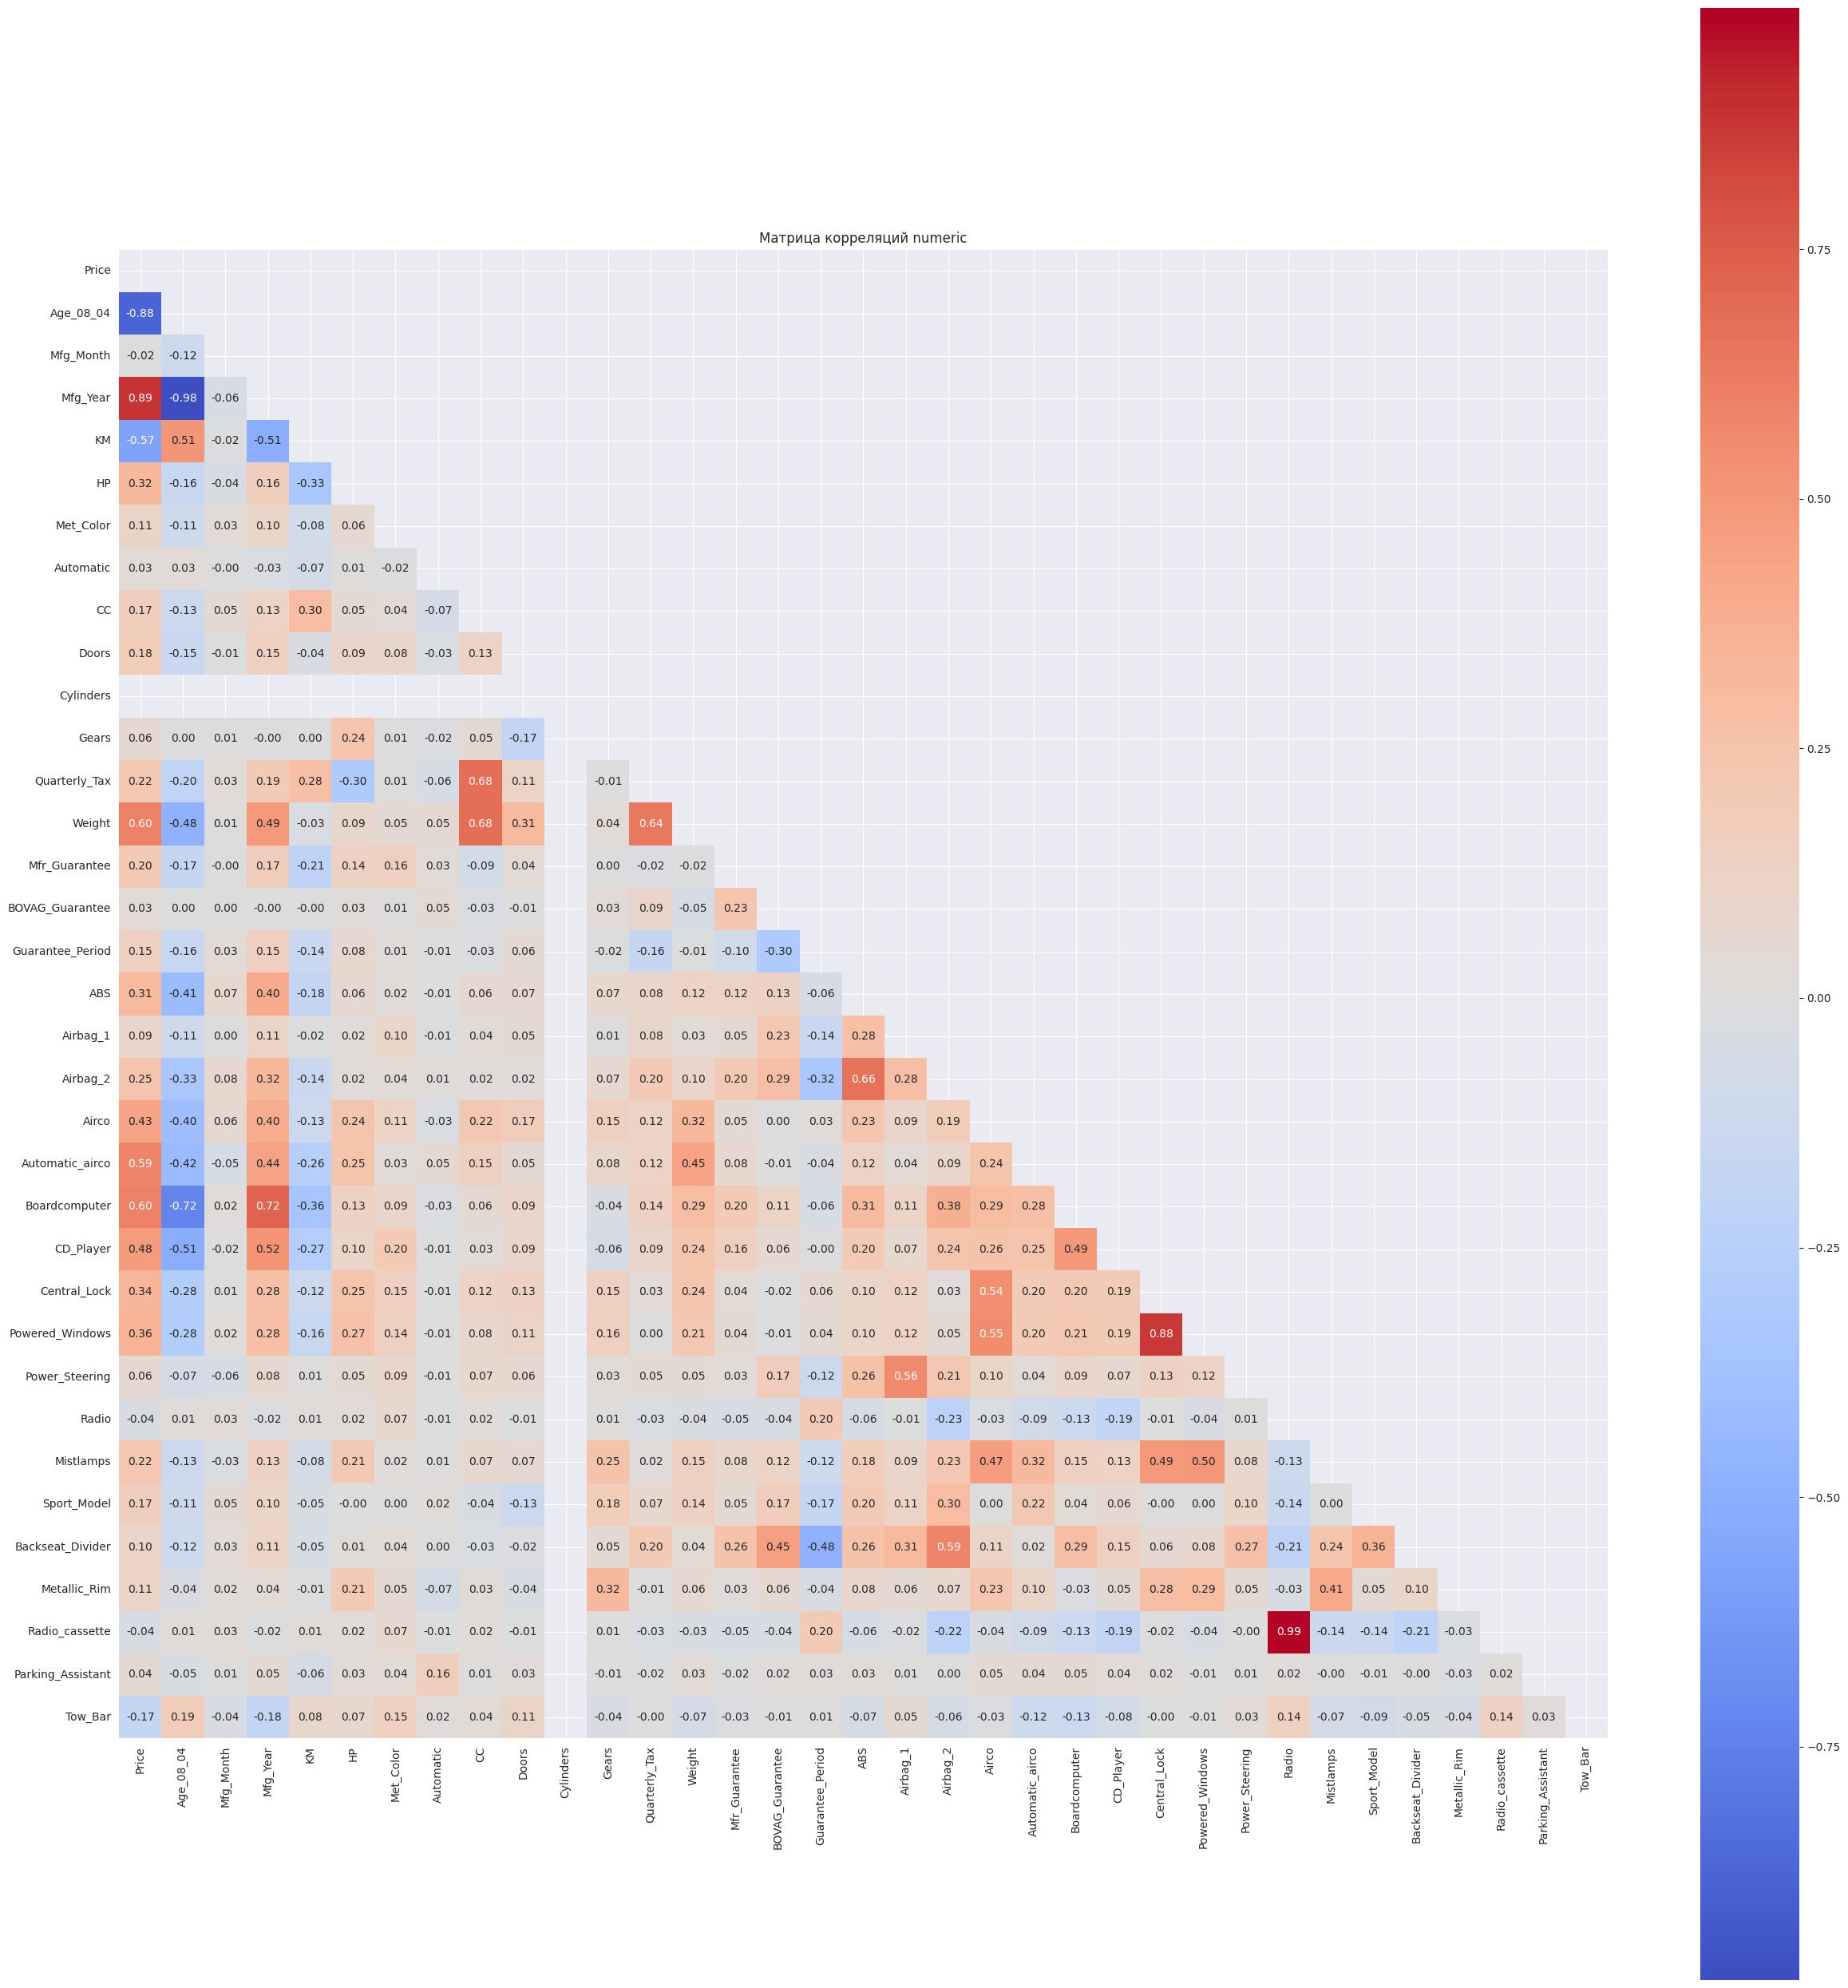

In [1696]:

numeric_cols = df.select_dtypes(include=['int64']).columns

if 'Id' in numeric_cols:
  numeric_cols = numeric_cols.drop('Id')

plt.figure(figsize=(25, 25))
correlation_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True)
plt.title('Матрица корреляций numeric')
plt.tight_layout()
plt.show()



# FEATURE ENGENEERING
ЗДЕСЬ ДОСТАЮ ТИП КУЗОВА(хэтч 3-5 дверей седан универсал и тд) И КОМПЛЕКТАЦИЮ(terra luna sol sport and so on) ИЗ ПОЛЯ MODEL

подсчёт опций и связанные параметры

one-hot-encoding для типа топлива и цвета(3 и 10 уникальных значений соотв.)

In [1697]:
df['KM_log'] = np.log1p(df['KM'])

fuel_dummies = pd.get_dummies(df['Fuel_Type'], prefix='Fuel')
df = pd.concat([df, fuel_dummies], axis=1)

color_dummies = pd.get_dummies(df['Color'], prefix='Color')
df = pd.concat([df, color_dummies], axis=1)

option_features = [
    'Met_Color', 'Automatic', 'Mfr_Guarantee', 'BOVAG_Guarantee',
    'ABS', 'Airbag_1', 'Airbag_2', 'Airco', 'Automatic_airco',
    'Boardcomputer', 'CD_Player', 'Central_Lock', 'Powered_Windows',
    'Power_Steering', 'Radio', 'Mistlamps', 'Sport_Model',
    'Backseat_Divider', 'Metallic_Rim', 'Radio_cassette',
    'Parking_Assistant', 'Tow_Bar'
]

df['Options_Score'] = df[option_features].sum(axis=1)

df['Options_x_Age'] = df['Options_Score'] * df['Age_08_04']
df['Options_x_KM'] = df['Options_Score'] * df['KM_log']

def find_complectation(model):
    model_upper = str(model).upper()

    if 'TERRA' in model_upper:
        return 'Terra'
    elif 'LUNA' in model_upper:
        return 'Luna'
    elif 'SOL' in model_upper:
        return 'Sol'
    elif 'COMFORT' in model_upper:
        return 'Comfort'
    elif 'EXECUTIVE' in model_upper:
        return 'Executive'
    elif 'G6' in model_upper:
        return 'G6'
    elif 'SPORT' in model_upper:
        return 'Sport'
    elif 'VVT I' in model_upper:
       return 'vvti'
    elif 'VVTI' in model_upper:
        return 'vvti'
    else:
        #print(model_upper + '\n')
        return 'Other'

df['Complectation'] = df['Model'].apply(find_complectation)
print(df['Complectation'].value_counts())
complectation_dummies = pd.get_dummies(df['Complectation'], prefix='Complectation')
df = pd.concat([df, complectation_dummies], axis=1)
df = df.drop('Complectation', axis=1)


def find_body_type(model):
    model_upper = str(model).upper()

    if 'HATCHB' in model_upper or '3DR' in model_upper or '3-DOORS' in model_upper:
        return 'Hatchback_3dr'
    elif '5DR' in model_upper or '5-DOORS' in model_upper or '5DR' in model_upper:
        return 'Hatchback_5dr'
    elif 'SEDAN' in model_upper:
        return 'Sedan'
    elif 'WAGON' in model_upper or 'STATION' in model_upper:
        return 'Wagon'
    elif 'LIFTB' in model_upper:
        return 'Liftback'
    elif 'VERSO' in model_upper:
        return 'Verso'
    else:
        #print(f"Неизвестный тип кузова: {model_upper}")
        return 'Other'

df['Body_Type'] = df['Model'].apply(find_body_type)
print(df['Body_Type'].value_counts())

body_dummies = pd.get_dummies(df['Body_Type'], prefix='Body')
df = pd.concat([df, body_dummies], axis=1)
df = df.drop('Body_Type', axis=1)


Complectation
Terra        895
Luna         217
Sol          148
G6            75
Other         65
vvti          17
Sport         12
Comfort        1
Executive      1
Name: count, dtype: int64
Body_Type
Hatchback_5dr    716
Hatchback_3dr    623
Wagon             83
Verso              5
Other              4
Name: count, dtype: int64


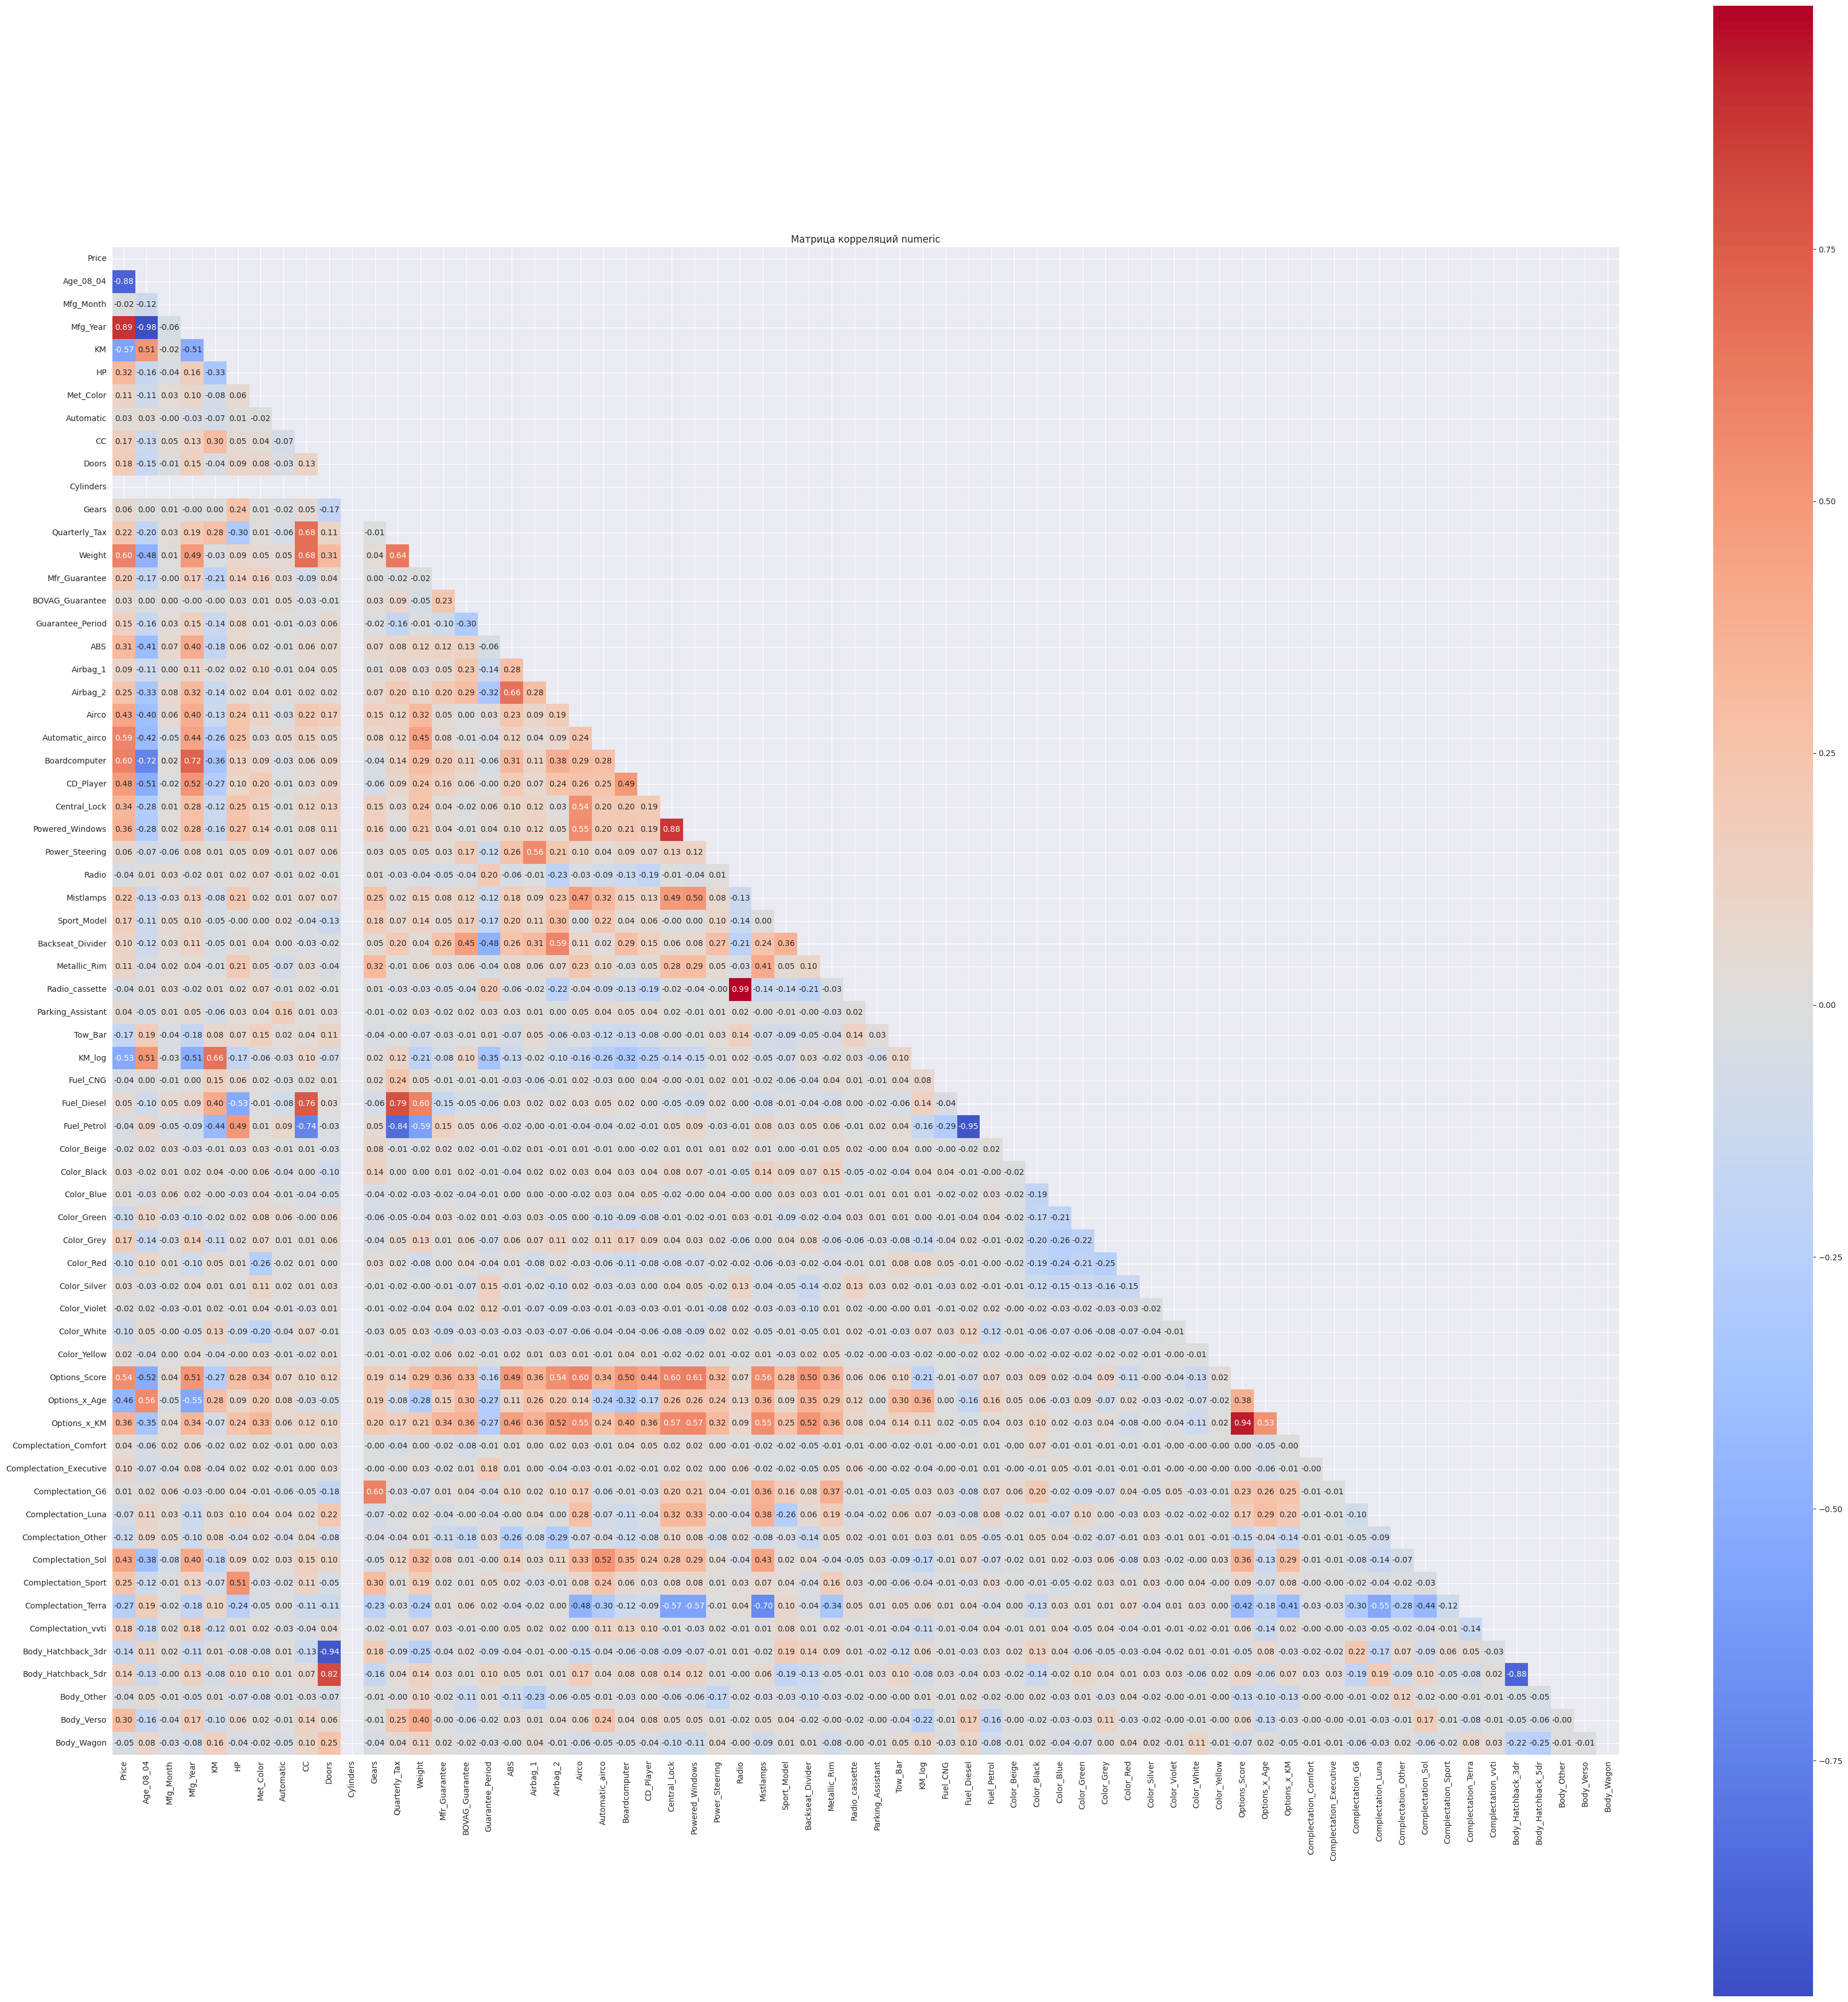

In [1698]:
numeric_cols = df.select_dtypes(include=['int64', 'float64', 'bool']).columns

if 'Id' in numeric_cols:
  numeric_cols = numeric_cols.drop('Id')

plt.figure(figsize=(35, 35))
correlation_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True)
plt.title('Матрица корреляций numeric')
plt.tight_layout()
plt.show()

удлание ненужных и сильно коррелирующих между собой признаков(по матрице коррелиаций)

я не удаляю низкокоррелирующие с ценой признаки. коэфф alpha у Lasso маленький

In [1699]:
cols_to_drop = [
    'Id',
    'Model', #слишком много уникальных. вытаскивать тип кузова(лифтбек или универсал)
    #мало смысла т.к. это отражается количеством дверей
    #вытаскивать комплектацию типа terra luna sol.. тоже нет смысла ведь полнота комплектации
    # кодируется бинарными признаками типо автоматического климата и тд
    'Mfg_Year', # высокая корреляция c Age
    'Mfg_Month', # зачем месяц без года
    'Cylinders', # все короллы четырехкотловые
    'Color', # сделали кодирование
    'Fuel_Type', # сделали кодирование
    'Radio_cassette', # высокая корреляция с Radio
    'Central_Lock', # высокая корреляция с электростеклоподъемниками. удалил центральный замок
    'Doors'
    # т.к. стеклоподъемники больше коррелируют с ценой
]

df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])


# РАЗБИЕНИЕ И МАСШТАБИРОВАНИЕ

## логарфмирование таргет поля с ценой происходит здесь.

In [1700]:
#y = df['Price']
#X = df.drop('Price', axis=1)

df['Price_log'] = np.log1p(df['Price'])

y = df['Price_log']
X = df.drop(['Price', 'Price_log'], axis=1)


X_train, X_test, y_train_log, y_test_log = train_test_split(X, y, test_size=0.25, random_state=42, shuffle=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ОБУЧЕНИЕ МОДЕЛИ И ПОДБОР ГИПЕРПАРАМЕТРОВ

In [1701]:
import time

start_time = time.time()
lr = LinearRegression()
lr.fit(X_train_scaled, y_train_log)
end_time = time.time()
print(f"Время обучения LinearRegression: {end_time - start_time:.4f} s")

ridge_params = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
start_time = time.time()
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2')
ridge_grid.fit(X_train_scaled, y_train_log)
end_time = time.time()
print(f"Время обучения Ridge: {end_time - start_time:.4f} s")
print(f"Лучшая alpha для Ridge: {ridge_grid.best_params_}")

lasso_params = {'alpha': [0.00001, 0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]}
start_time = time.time()
lasso_grid = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=5, scoring='r2')
lasso_grid.fit(X_train_scaled, y_train_log)
end_time = time.time()
print(f"Время обучения Lasso: {end_time - start_time:.4f} s")
print(f"Лучшая alpha для Lasso: {lasso_grid.best_params_}")

Время обучения LinearRegression: 0.0971 s
Время обучения Ridge: 0.3249 s
Лучшая alpha для Ridge: {'alpha': 10.0}
Время обучения Lasso: 1.0515 s
Лучшая alpha для Lasso: {'alpha': 0.001}


время обучения поменялось

# Проверка на тестовой выборке

In [1702]:
models = {
    'Linear Regression': lr,
    'Ridge': ridge_grid.best_estimator_,
    'Lasso': lasso_grid.best_estimator_
}

for name, model in models.items():
    y_train_pred = model.predict(X_train_scaled)

    y_train_pred =  np.expm1(y_train_pred)
    y_train =  np.expm1(y_train_log)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)

    print(f"{name}:")
    print(f"RMSE: {train_rmse:.2f}")
    print(f"MAE: {train_mae:.2f}")
    print(f"R2: {train_r2:.3f}")
    print()


for name, model in models.items():
    y_pred = model.predict(X_test_scaled)

    y_pred = np.expm1(y_pred)
    y_test = np.expm1(y_test_log)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{name}:")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R2: {r2:.3f}")

Linear Regression:
RMSE: 995.94
MAE: 744.29
R2: 0.926

Ridge:
RMSE: 996.41
MAE: 744.57
R2: 0.926

Lasso:
RMSE: 992.03
MAE: 743.56
R2: 0.927


Linear Regression:
RMSE: 1017.48
MAE: 803.65
R2: 0.915

Ridge:
RMSE: 1014.91
MAE: 802.53
R2: 0.916

Lasso:
RMSE: 999.90
MAE: 796.96
R2: 0.918


# Финальное

R2: 0.918
Lasso, alpha = 0.001

больше я не выжал

полиномиальные фичи для оснвных самых коррелирующих параметров я пробовал но результата не заметил.
да и параметры я не удалял - их много.